# Lab: Simple Linear Regression with scikit-learn

In this lab, you'll learn how to fit a **Simple Linear Regression** model using scikit-learn. By the end, you'll be familiar with the core sklearn API pattern:

1. **Instantiate** the model
2. **Fit** the model to data
3. **Inspect** the learned parameters

We'll use the *Advertising* dataset, which records TV advertising spend (in thousands of dollars) and sales (in thousands of units) across 200 markets.

---

## 1. Setup

Let's import the libraries we need and configure the plotting style.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

# Plotting configuration
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["figure.dpi"] = 150

## 2. Load & Inspect the Data

In [6]:
# Load the dataset
data = pd.read_csv("../data/raw/advertising.csv")

# Preview the first 5 rows
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [7]:
# General information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


## 3. Prepare the Data

For this lab, we only need the `TV` column (our feature) and the `Sales` column (our target). We'll also lowercase the column names for convenience.

In [10]:
# Drop columns we won't be using
sales_df = data.drop(columns=["Radio", "Newspaper"])

# Lowercase the column names
sales_df.columns = [col.lower() for col in sales_df.columns]

sales_df.head()

,tv,sales
0,230.1,22.1
1,44.5,10.4
2,17.2,12.0
3,151.5,16.5
4,180.8,17.9


## 4. Visualize the Relationship

Before fitting a model, let's plot TV spend against sales to get an intuition for the relationship.

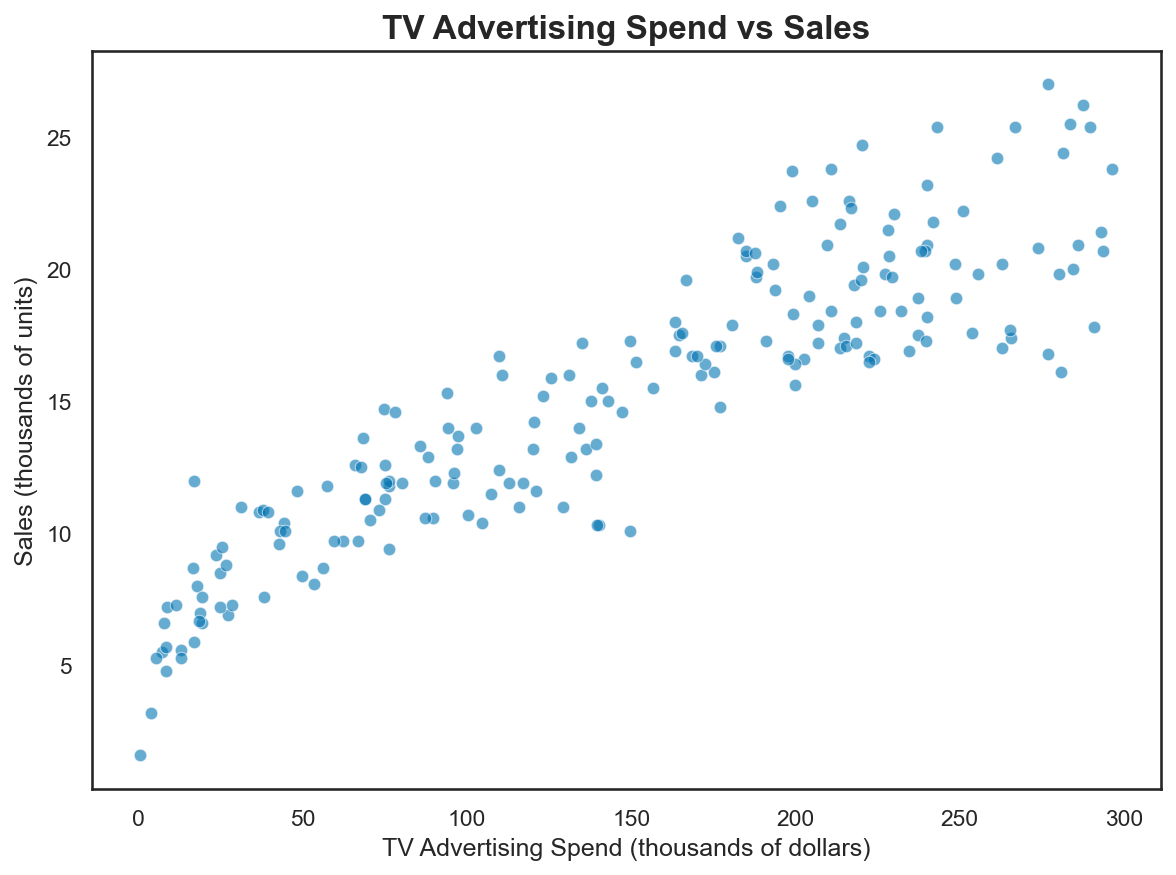

In [11]:
plt.figure()
sns.scatterplot(data=sales_df, x="tv", y="sales", alpha=0.6)
plt.title("TV Advertising Spend vs Sales", fontsize=16, fontweight="bold")
plt.xlabel("TV Advertising Spend (thousands of dollars)")
plt.ylabel("Sales (thousands of units)")
plt.tight_layout()
plt.show()

There is a clear **positive linear trend**: markets with higher TV ad spend tend to have higher sales.

---

## 5. Fit the Model with scikit-learn

Now let's use `LinearRegression` from scikit-learn to fit a line to this data.

The three-step sklearn pattern is:
1. **Instantiate** — create the model object
2. **Fit** — train the model on data
3. **Inspect** — read the learned parameters

In [12]:
# Define feature (X must be 2D) and target
X = sales_df[["tv"]]
y = sales_df["sales"]

# Step 1: Instantiate the model
model = LinearRegression()

# Step 2: Fit the model to the full dataset
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 6. Inspect the Learned Parameters

After fitting, sklearn stores the learned parameters as attributes:
- `model.intercept_` — the bias term (β₀)
- `model.coef_` — the slope(s) (β₁, ...)

In [13]:
print(f"Intercept (β₀):  {model.intercept_:.4f}")
print(f"Coefficient (β₁): {model.coef_[0]:.4f}")
print()
print("Interpretation:")
print(f"  When TV spend is $0, predicted sales = {model.intercept_:.2f}k units.")
print(f"  For every additional $1,000 spent on TV ads, sales increase by ~{model.coef_[0]*1000:.0f} units.")

Intercept (β₀):  6.9748
Coefficient (β₁): 0.0555

Interpretation:
  When TV spend is $0, predicted sales = 6.97k units.
  For every additional $1,000 spent on TV ads, sales increase by ~55 units.


## 7. Plot the Regression Line

Let's overlay the fitted line on the scatter plot to see how well it captures the trend.

/Users/ibrahimkocyigit/Documents/repos/kocyigit-dsml/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


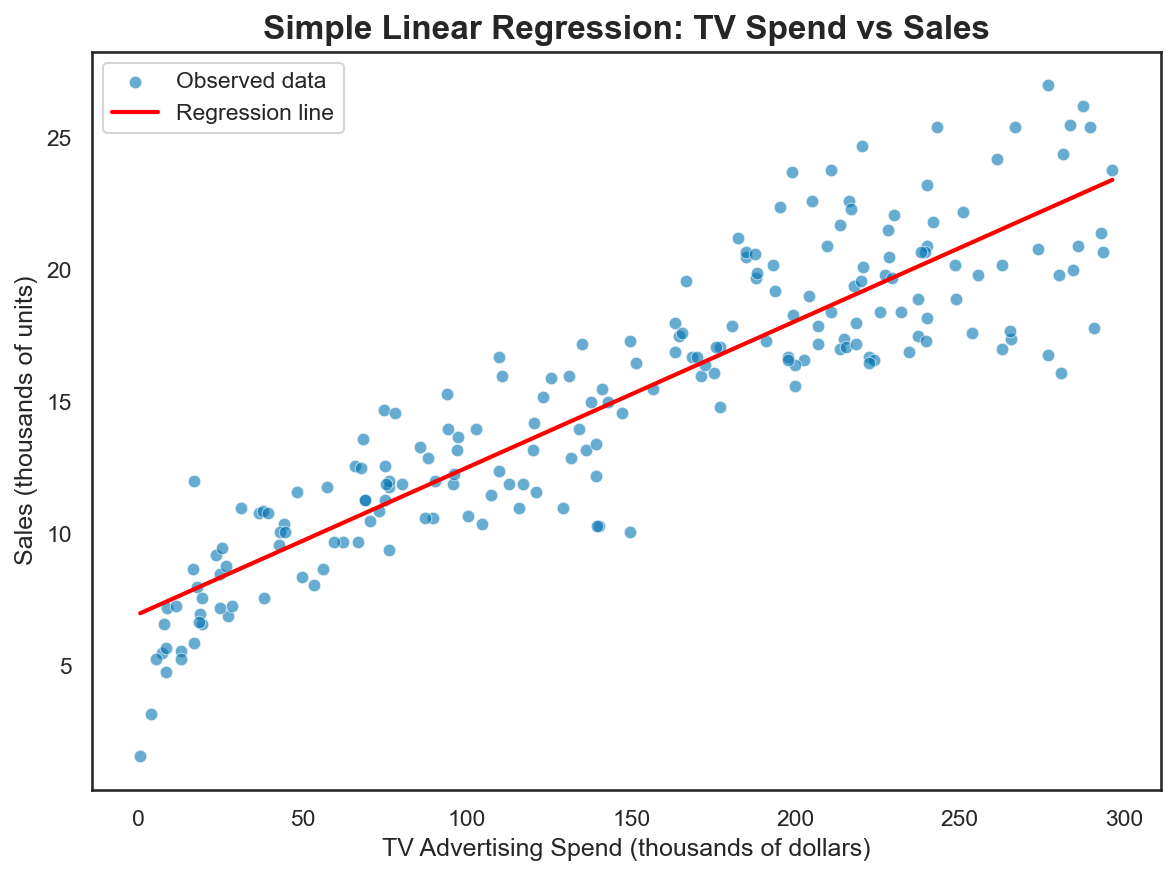

In [14]:
import numpy as np

# Generate a smooth range of X values for the line
X_line = np.linspace(sales_df["tv"].min(), sales_df["tv"].max(), 200).reshape(-1, 1)
y_line = model.predict(X_line)

plt.figure()
sns.scatterplot(data=sales_df, x="tv", y="sales", alpha=0.6, label="Observed data")
plt.plot(X_line, y_line, color="red", linewidth=2, label="Regression line")
plt.title("Simple Linear Regression: TV Spend vs Sales", fontsize=16, fontweight="bold")
plt.xlabel("TV Advertising Spend (thousands of dollars)")
plt.ylabel("Sales (thousands of units)")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Summary

In this lab you learned how to use scikit-learn's `LinearRegression` to fit a simple linear regression model:

| Step | Code | What it does |
|------|------|--------------|
| Instantiate | `model = LinearRegression()` | Creates the model object |
| Fit | `model.fit(X, y)` | Finds the best-fit line through the data |
| Inspect | `model.intercept_`, `model.coef_` | Reads the learned intercept and slope |
| Predict | `model.predict(X_new)` | Generates predictions for new inputs |

This same three-step pattern — **instantiate → fit → inspect/predict** — applies to every model in scikit-learn.

---

**Next:** [Multiple Linear Regression Theory](./05_multiple_linear_regression_theory.md)